In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Data Pre-Processing**

In [13]:
# Panggil no2 stasiun
import os
output_path = r'D:\Kuliah UNDIP\Semester 7\TA\PENGOLAHAN\github\output'

# data no2 stasiun v1 (07-09)
no2_station = pd.read_excel(os.path.join(output_path, 'no2_station_interpolated_smoothed.xlsx'))
no2_station['time'] = pd.to_datetime(no2_station['date'])
no2_station.set_index('time', inplace=True)
no2_station.drop('date', axis=1, inplace=True)

# data no2 stasiun v2 (12-14)
no2_station_v2 = pd.read_excel(os.path.join(output_path, 'no2_station_interpolated_smoothed_v2.xlsx'))
no2_station_v2['time'] = pd.to_datetime(no2_station_v2['date'])
no2_station_v2.set_index('time', inplace=True)
no2_station_v2.drop('date', axis=1, inplace=True)

# data no2 vcd
no2_vcd = pd.read_excel(os.path.join(output_path, 'no2_vcd_timeseries.xlsx'))
no2_vcd['time'] = pd.to_datetime(no2_vcd['time'])
no2_vcd.set_index('time', inplace=True)


In [14]:
# Merge data stasiun dan vcd berdasarkan index waktu
df = pd.merge(
    no2_station['no2_station_smooth'],
    no2_vcd[['no2_vcd_filled', 'pb', 'ws', 'temp', 'wd', 'tp', 'sr']],
    left_index=True, right_index=True
).dropna()

# jadikan time sebagai index
df['time'] = df.index
df = df.set_index('time')

df

,no2_station_smooth,no2_vcd_filled,pb,ws,temp,wd,tp,sr
time,,,,,,,,
2025-01-01,119.179311,0.000033,418.524353,2.515845,299.359001,136.929115,0.510950,242.600891
2025-01-02,119.013596,0.000034,346.394928,2.146850,298.836231,229.106330,0.852020,212.494873
2025-01-03,118.994996,0.000034,343.399597,1.338448,299.185204,179.725113,0.070202,291.247131
2025-01-04,118.998705,0.000039,369.372681,1.500991,299.770238,201.761385,0.141608,326.774994
2025-01-05,119.000001,0.000033,373.431732,2.529847,299.011377,205.579167,0.874491,226.122269
...,...,...,...,...,...,...,...,...
2025-06-26,81.793226,0.000030,488.874084,2.977641,299.622714,300.144320,0.018092,231.959015
2025-06-27,112.054100,0.000030,415.720917,2.304440,299.698370,302.846453,0.052420,250.410553
2025-06-28,117.928547,0.000038,460.405426,2.556044,298.957387,311.583979,0.448278,219.767868


# **Conversion Dobson Unit** 

In [15]:
# VCD Proxy BLH
df['no2_vcd_proxy'] = df['no2_vcd_filled'] / df['pb']  

# Dobson unit conversion
df['no2_vcd_du'] = df['no2_vcd_proxy'] * 2241.15

df

,no2_station_smooth,no2_vcd_filled,pb,ws,temp,wd,tp,sr,no2_vcd_proxy,no2_vcd_du
time,,,,,,,,,,
2025-01-01,119.179311,0.000033,418.524353,2.515845,299.359001,136.929115,0.510950,242.600891,7.915907e-08,0.000177
2025-01-02,119.013596,0.000034,346.394928,2.146850,298.836231,229.106330,0.852020,212.494873,9.835878e-08,0.000220
2025-01-03,118.994996,0.000034,343.399597,1.338448,299.185204,179.725113,0.070202,291.247131,1.003228e-07,0.000225
2025-01-04,118.998705,0.000039,369.372681,1.500991,299.770238,201.761385,0.141608,326.774994,1.044358e-07,0.000234
2025-01-05,119.000001,0.000033,373.431732,2.529847,299.011377,205.579167,0.874491,226.122269,8.902419e-08,0.000200
...,...,...,...,...,...,...,...,...,...,...
2025-06-26,81.793226,0.000030,488.874084,2.977641,299.622714,300.144320,0.018092,231.959015,6.130384e-08,0.000137
2025-06-27,112.054100,0.000030,415.720917,2.304440,299.698370,302.846453,0.052420,250.410553,7.209446e-08,0.000162
2025-06-28,117.928547,0.000038,460.405426,2.556044,298.957387,311.583979,0.448278,219.767868,8.184417e-08,0.000183


In [16]:
print(df.describe())

       no2_station_smooth  no2_vcd_filled          pb          ws        temp  \
count          181.000000      181.000000  181.000000  181.000000  181.000000   
mean            76.414402        0.000035  381.760349    2.021529  299.361704   
std             45.483112        0.000011   90.187128    1.147988    0.504553   
min              8.211287        0.000000  205.634415    0.341413  297.764406   
25%             32.461427        0.000029  330.087463    1.211785  299.003496   
50%             88.907010        0.000035  369.372681    1.656645  299.405744   
75%            107.111782        0.000040  421.065247    2.639759  299.720656   
max            179.123101        0.000091  736.783691    5.444397  300.577533   

               wd          tp          sr  no2_vcd_proxy  no2_vcd_du  
count  181.000000  181.000000  181.000000   1.810000e+02  181.000000  
mean   207.510014    0.902333  243.812928   9.554787e-08    0.000214  
std     80.235425    1.845813   65.280186   3.746364e-08 

# **Heatmap Spearman**

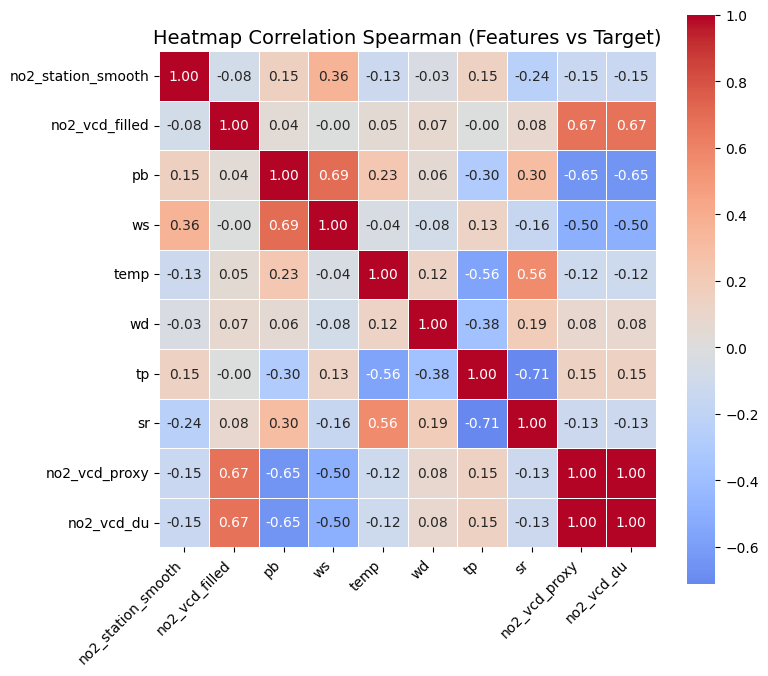

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# merge selected feature + target
df_corr = df.copy()

# compute correlation matrix (Spearman)
corr_matrix = df_corr.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # add number
    fmt=".2f",         
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Heatmap Correlation Spearman (Features vs Target)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# **Spike and Plot Time Series**

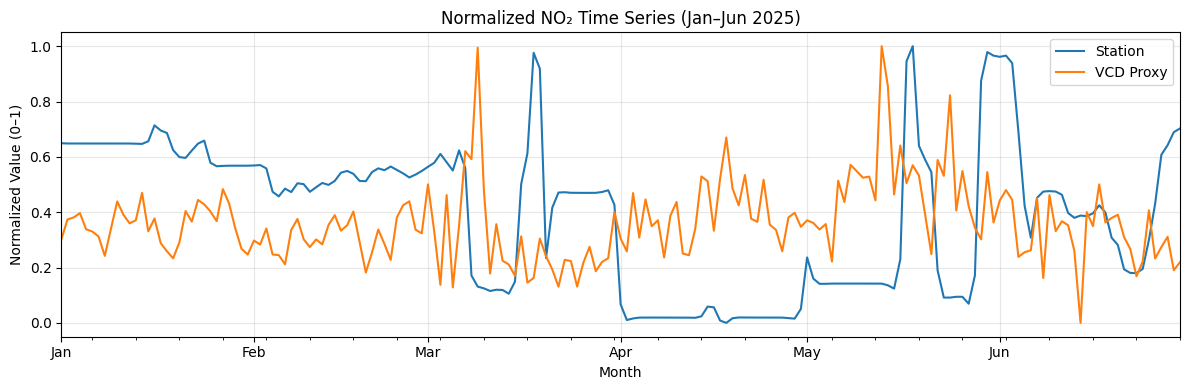

In [18]:
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler

df_plot = pd.concat([
    df['no2_station_smooth'],
    df['no2_vcd_proxy']
], axis=1).dropna().copy()

# pastikan datetime index
df_plot.index = pd.to_datetime(df_plot.index)

# scaling
scaler = MinMaxScaler()
df_plot_scaled = pd.DataFrame(
    scaler.fit_transform(df_plot),
    index=df_plot.index,
    columns=['Station', 'VCD Proxy']
)

# plot
fig, ax = plt.subplots(figsize=(12, 4))

df_plot_scaled.plot(ax=ax, linewidth=1.5)

# format waktu → bulanan
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# styling
ax.set_title("Normalized NO₂ Time Series (Jan–Jun 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized Value (0–1)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [19]:
ts = df['no2_station_smooth'].dropna()

threshold = ts.mean() + 2 * ts.std()
spikes = ts[ts > threshold]

# tampilkan dengan datetime
print(spikes)

time
2025-03-18    175.013897
2025-05-17    169.836128
2025-05-18    179.123101
2025-05-30    175.468656
2025-05-31    173.267873
2025-06-01    172.540913
2025-06-02    173.279362
2025-06-03    168.656540
Name: no2_station_smooth, dtype: float64


In [20]:
tv = df['no2_vcd_filled'].dropna()

threshold = tv.mean() + 2 * tv.std()

spikes_vcd = tv[tv > threshold]

print(spikes_vcd)

time
2025-03-09    0.000076
2025-05-13    0.000091
2025-05-14    0.000075
Name: no2_vcd_filled, dtype: float64


# **Uji Asumsi Klasik Regresi**

In [ ]:
from scipy.stats import shapiro, pearsonr, spearmanr
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
df_uji = df.copy()

In [31]:
# Definisikan variabel target dan fitur
df_uji['log_vcd_du'] = np.log1p(df_uji['no2_vcd_du'])
df_uji['log_station_smooth'] = np.log1p(df_uji['no2_station_smooth'])

x = df_uji['log_vcd_du'].dropna()
y = df_uji['log_station_smooth'].dropna()


print(len(x), len(y))

181 181


no2_station_smooth : W = 0.9193, p-value = 1.9146e-08
no2_vcd_du         : W = 0.8507, p-value = 2.5009e-12


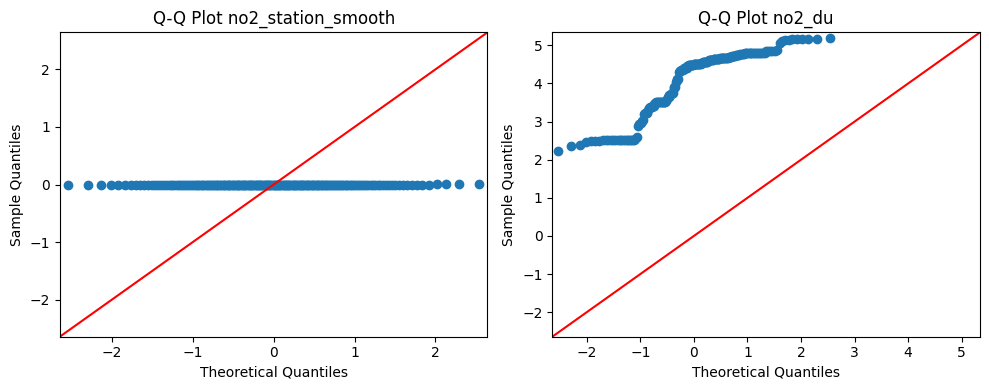

In [32]:
# Uji Normalitas Shapiro-Wilk
stat_x, p_x = shapiro(x)
stat_y, p_y = shapiro(y)
print(f"no2_station_smooth : W = {stat_x:.4f}, p-value = {p_x:.4e}")
print(f"no2_vcd_du         : W = {stat_y:.4f}, p-value = {p_y:.4e}")

# Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sm.qqplot(x, line='45', ax=axes[0])
axes[0].set_title('Q-Q Plot no2_station_smooth')

sm.qqplot(y, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot no2_du')

plt.tight_layout()
plt.show()



# **Validation Test Statistic**

In [36]:
df_uji = df.copy()
df_uji['log_vcd_du'] = np.log1p(df_uji['no2_vcd_du'])
df_uji['ws_pb'] = df_uji['ws'] * df_uji['pb']
df_uji['wd_sin'] = np.sin(np.deg2rad(df_uji['wd']))
df_uji['wd_cos'] = np.cos(np.deg2rad(df_uji['wd']))
df_uji['log_ws']  = np.log1p(df_uji['ws'])
df_uji['log_tp']  = np.log1p(df_uji['tp'])
df_uji = df_uji.dropna()

In [37]:
# Spearman Correlation
from scipy import stats
spearman_r_du, p_spearman_du = stats.spearmanr(df_uji['no2_station_smooth'], df_uji['no2_vcd_du'])
spearman_r_filled, p_spearman_filled = stats.spearmanr(df_uji['no2_station_smooth'], df_uji['no2_vcd_filled'])

# Pearson Correlation
pearson_r_du, p_pearson_du = stats.pearsonr(df_uji['no2_station_smooth'], df_uji['no2_vcd_du'])
pearson_r_filled, p_pearson_filled = stats.pearsonr(df_uji['no2_station_smooth'], df_uji['no2_vcd_filled'])

print(f"\nKorelasi Spearman Rank")
print(f"Spearman ρ proxy (BLH Correction): {spearman_r_du:.4f}  (p={p_spearman_du:.4f})")
print(f"Spearman ρ real: {spearman_r_filled:.4f}  (p={p_spearman_filled:.4f})")

print(f"\nKorelasi Pearson")
print(f"Pearson r proxy (BLH Correction): {pearson_r_du:.4f}  (p={p_pearson_du:.4f})")
print(f"Pearson r real: {pearson_r_filled:.4f}  (p={p_pearson_filled:.4f})")


Korelasi Spearman Rank
Spearman ρ proxy (BLH Correction): -0.1495  (p=0.0446)
Spearman ρ real: -0.0787  (p=0.2920)

Korelasi Pearson
Pearson r proxy (BLH Correction): -0.2079  (p=0.0050)
Pearson r real: -0.1371  (p=0.0658)


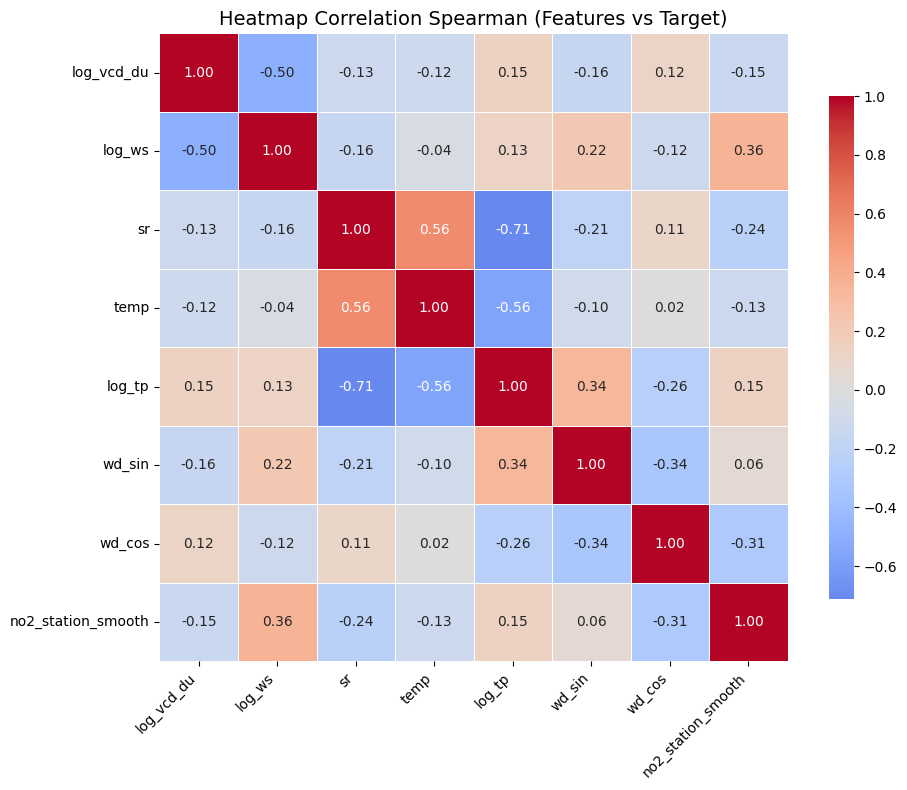

In [38]:
# Uji korelasi spearman
features_clean = ['log_vcd_du', 'log_ws', 'sr', 'temp', 'log_tp','wd_sin','wd_cos']

correlation_matrix = df_uji[features_clean + ['no2_station_smooth']].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,        # add number
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Heatmap Correlation Spearman (Features vs Target)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [39]:
import statsmodels.api as sm
features_clean = ['log_vcd_du', 'log_ws', 'sr', 'temp', 'log_tp','wd_sin','wd_cos']
X = df_uji[features_clean]
y = df_uji['no2_station_smooth']

# tambah intercept
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()

print(model.summary())

# save summary ke file teks

output_path = r'D:\Kuliah UNDIP\Semester 7\TA\PENGOLAHAN\github\output'
with open(os.path.join(output_path, 'regression_summary.txt'), 'w') as f:
    f.write(model.summary().as_text())  



                            OLS Regression Results                            
Dep. Variable:     no2_station_smooth   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                     9.997
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.83e-10
Time:                        14:23:38   Log-Likelihood:                -916.53
No. Observations:                 181   AIC:                             1849.
Df Residuals:                     173   BIC:                             1875.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1504.4511   2148.903     -0.700      0.4

R² model linear: 0.2880


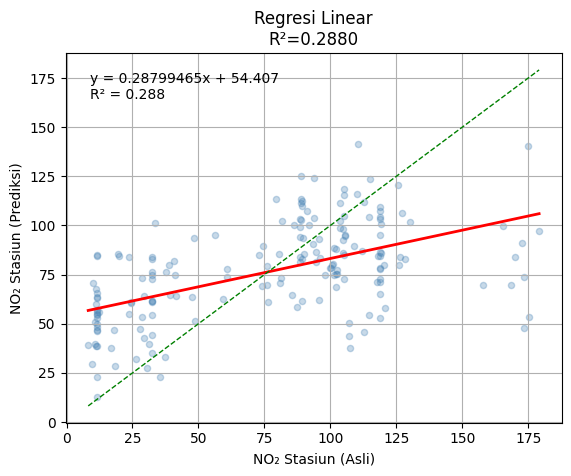

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


Xtr = df_uji[features_clean]
ytr = df_uji['no2_station_smooth']

m_lin = LinearRegression().fit(Xtr, ytr)
y_pred = m_lin.predict(Xtr)
r2 = r2_score(ytr, y_pred)
print(f"R² model linear: {r2:.4f}")
plt.scatter(ytr, y_pred, alpha=0.3, s=20, color='steelblue')

# garis regresi
m, b = np.polyfit(ytr, y_pred, 1)
x_line = np.linspace(ytr.min(), ytr.max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2)

# plot line 1:1
plt.plot(x_line, x_line, color='green', linestyle='--', linewidth=1)

# Tambah persamaan di plot
plt.text(
    0.05, 0.95,
    f'y = {m:.8f}x + {b:.3f}\nR² = {r2:.3f}',
    transform=plt.gca().transAxes,
    verticalalignment='top'
)


plt.xlabel("NO₂ Stasiun (Asli)")
plt.ylabel("NO₂ Stasiun (Prediksi)")
plt.title(f"Regresi Linear\nR²={r2:.4f}")
plt.grid()
plt.show()


"Analisis korelasi antara NO₂ VCD satelit dan konsentrasi 
NO₂ permukaan dari stasiun pemantauan menunjukkan korelasi 
yang sangat lemah -0.1495  (p=0.0446), konsisten dengan 
studi sebelumnya yang melaporkan rendahnya korelasi antara 
kedua variabel ini pada skala titik (misal: Lamsal et al., 
2008; Novotny et al., 2011). 

Perbedaan ini disebabkan oleh:
(1) perbedaan representasi spasial antara pengukuran kolom 
    vertikal satelit (~3.5 × 5.5 km²) dan pengukuran titik 
    stasiun permukaan,
(2) perbedaan fisik antara konsentrasi NO₂ permukaan dan 
    kolom vertikal atmosfer yang mencakup seluruh lapisan 
    troposfer, dan  
(3) pengaruh kondisi meteorologi lokal terhadap dispersi 
    NO₂ permukaan yang tidak tercermin dalam data satelit.

Oleh karena itu, kalibrasi langsung antara NO₂ VCD dan 
NO₂ stasiun tidak dilakukan. NO₂ VCD digunakan sebagai 
proksi distribusi spasial polusi NO₂ relatif."

Referensi yang bisa dikutip

Lamsal et al. (2008) — Ground-level nitrogen dioxide concentrations inferred from the satellite-borne Ozone Monitoring Instrument
Novotny et al. (2011) — National satellite-based land-use regression: NO₂ in the United States
Li et al. (2019) — paper RF-STK yang kamu pakai, juga menyebut limitasi ini